Jose E Rodriguez Rios

and a classmate

Using a machine learning model we use it to predict the next possible scores in stocks which is gonna be diffrent afrom the initial scan

In [10]:
import numpy as np
import pandas as pd
import requests
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt  

In [11]:
df = pd.read_csv('AMZN20233.csv') #para manejar data frames

In [12]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-04-12,153.692505,155.098999,150.382996,150.787506,150.787506,55178000
1,2022-04-13,150.018494,156.024994,149.600006,155.541000,155.541000,53390000
2,2022-04-14,155.389999,155.897003,151.472000,151.706497,151.706497,51598000
3,2022-04-18,151.523499,154.039505,150.250504,152.785004,152.785004,46514000
4,2022-04-19,152.029495,158.649002,151.550507,158.115494,158.115494,54926000


In [13]:
df.columns 

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [14]:
data = df.copy() 
year_month = '2022-04' #YYYY-MM-DD 
date_year_month_df = data[data['Date'].str.startswith(year_month)].copy() 
date_year_month_df = date_year_month_df.loc[date_year_month_df['Date'].str.startswith(year_month)]
date_year_month_df['Date'] = date_year_month_df['Date'].str.split('-').str[2] # [2022,12,13]

dates = date_year_month_df['Date'].to_list()
prices = date_year_month_df['Close'].to_list() 

In [15]:
print(dates)
print(prices)

['12', '13', '14', '18', '19', '20', '21', '22', '25', '26', '27', '28', '29']
[150.787506, 155.541, 151.706497, 152.785004, 158.115494, 153.998001, 148.296005, 144.350006, 146.074005, 139.391006, 138.167007, 144.596497, 124.281502]


#Train model

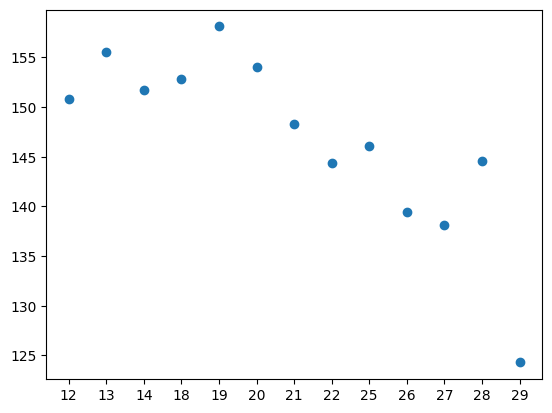

In [16]:
plt.scatter(dates, prices)

In [17]:
dates = np.array(dates).reshape(-1,1) 
prices = np.array(prices)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(dates, prices)

In [19]:
linear_model = SVR(kernel = 'linear', C=1e3)
rbf = SVR(kernel='rbf', C=1e3, gamma=0.1) 

linear_model.fit(X_train, y_train) 
rbf.fit(X_train, y_train )

SVR(C=1000.0, gamma=0.1)

#prediccion

In [20]:
y_pred = linear_model.predict(X_test) 
print('y_pred', y_pred) 
print('y_test', y_test)

y_pred [150.00725375 143.66788313 144.5735075  147.29038063]
y_test [158.115494 139.391006 146.074005 144.350006]


In [21]:
predict2 = rbf.predict(X_test) 
print('predict2: ', predict2) 
print('y_test', y_test)

predict2:  [155.41090432 115.65743723  99.88095822 136.37001764]
y_test [158.115494 139.391006 146.074005 144.350006]


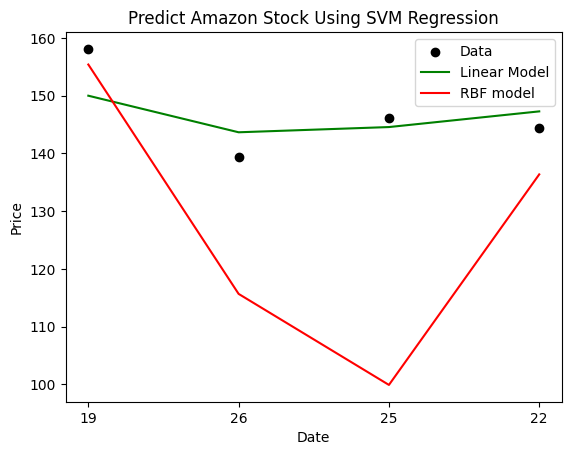

In [22]:
plt.scatter(X_test[:,0], y_test, c='k', label='Data')
plt.plot(X_test[:,0], linear_model.predict(X_test), c='g', label = 'Linear Model')
plt.plot(X_test[:,0], rbf.predict(X_test), c='r', label='RBF model')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Predict Amazon Stock Using SVM Regression')
plt.legend()
plt.show()

In [23]:
y_test.min()


139.391006

In [24]:
y_test.max()

158.115494